In [5]:
!pwd
# 현재 작업하고 있는 폴더(working directory)

/home/govlept1004/jupyter_home


In [2]:
import os # 폴더 경로 생성하기 위해
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator # 입력데이터 처리
from tensorflow.keras.applications import VGG16  
# VGG16은 성능은 좋지 않지만 알기 쉬운 pretrained network. 나중에는 EfficientNet 이거 사용함
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

In [3]:
import warnings
warnings.filterwarnings('ignore')  
# 중요하지않은 경고 알림을 제거해주는 코드

In [6]:
train_dir = './data/cat_dog_small/train'  # 학습용 이미지가 들어가 있는 폴더(상대경로)
validation_dir = './data/cat_dog_small/validation'

In [7]:
# ImageDataGenerator를 생성. 당연히 2개 생성

# train용 1개 - 증식설정이 들어가야되요
train_datagen = ImageDataGenerator(rescale=1/255.0,
                                  rotation_range=30,
                                  width_shift_range=0.1,
                                  height_shift_range=0.1,
                                  shear_range=0.2,
                                  zoom_range=0.2,
                                  horizontal_flip=True,
                                  vertical_flip=False,
                                  fill_mode='nearest')

# validation용 1개 -평가에는 증식이 들어가면 안되요!
validation_datagen = ImageDataGenerator(rescale=1/255.0)

In [8]:
# ImageDataGenerator 설정
train_generator = train_datagen.flow_from_directory(
    train_dir,
    classes=['cats','dogs'],
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    classes=['cats','dogs'],
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [9]:
# model 구현

model_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150,150,3))

model_base.trainable = False  # 있는 것을 그대로 사용할거란 코드, VGG16 안의 convolution Layer를 동결(중요!!)하는 코드

model = Sequential()

model.add(model_base)  # 특징 추출하는 부분(이미지 1장이 3차원)

model.add(Flatten())  # classifier로 넣어야 해요(이미지 1장이 1차원)

# hidden layer
model.add(Dense(units=128))
model.add(BatchNormalization())  # 성능 향상을 위해 BatchNormalization을 사용해요
model.add(Activation('relu'))

model.add(Dropout(rate=0.2))  
# Dropout은 Activation 뒤에 위차하는게 좋아요(Dense뒤에 위치)
# 일반적으로 convolution Layer에서는 Dropout을 사용하지 않아요

# 규제를 너무 많이 넣으면 오히려 성능이 떨어질 수 있다.
# Batch랑 Drop을 둘 다 있으면 규제가 두개니까 드랍아웃을 보통 0.2로 많이 잡음. 드랍만 있으면 일반적으로 0.5 사용

# output layer
model.add(Dense(units=1,
               activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dense (Dense)               (None, 128)               1048704   
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 128)               0         
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                        

In [10]:
# model 설정
model.compile(optimizer=Adam(learning_rate=1e-3),
             loss='binary_crossentropy',
             metrics=['accuracy']) 

In [11]:
#model 학습
history = model.fit(train_generator,
                   steps_per_epoch=100,
                   epochs=30,
                   validation_data=validation_generator,
                   validation_steps=50,
                   verbose=1)

Epoch 1/30
100/100 [==============================] - 12s 96ms/step - loss: 0.4515 - accuracy: 0.8020 - val_loss: 0.3736 - val_accuracy: 0.8380
Epoch 2/30
100/100 [==============================] - 8s 85ms/step - loss: 0.3326 - accuracy: 0.8490 - val_loss: 0.2960 - val_accuracy: 0.8780
Epoch 3/30
100/100 [==============================] - 9s 85ms/step - loss: 0.2817 - accuracy: 0.8760 - val_loss: 0.3523 - val_accuracy: 0.8580
Epoch 4/30
100/100 [==============================] - 9s 86ms/step - loss: 0.2921 - accuracy: 0.8690 - val_loss: 0.2725 - val_accuracy: 0.8870
Epoch 5/30
100/100 [==============================] - 9s 85ms/step - loss: 0.2646 - accuracy: 0.8815 - val_loss: 0.2723 - val_accuracy: 0.8930
Epoch 6/30
100/100 [==============================] - 9s 85ms/step - loss: 0.2597 - accuracy: 0.8885 - val_loss: 0.2739 - val_accuracy: 0.8900
Epoch 7/30
100/100 [==============================] - 9s 86ms/step - loss: 0.2462 - accuracy: 0.8965 - val_loss: 0.2926 - val_accuracy: 0.876

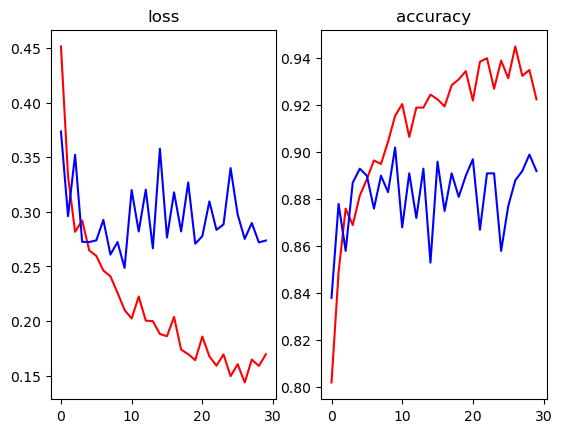

In [12]:
# 그래프
fig = plt.figure()

ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

ax1.set_title('loss')
ax1.plot(history.history['loss'], color='r')
ax1.plot(history.history['val_loss'], color='b')

ax2.set_title('accuracy')
ax2.plot(history.history['accuracy'], color='r')
ax2.plot(history.history['val_accuracy'], color='b')

plt.show()

In [14]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  ㅛ
Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [27]:
# 고양이와 강아지 이진분류 문제를
# VGG16을 이용한 Fine tuning으로 모델을 구현해 보아요

import os # 폴더 경로 생성하기 위해
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator # 입력데이터 처리
from tensorflow.keras.applications import VGG16  
# VGG16은 성능은 좋지 않지만 알기 쉬운 pretrained network. 나중에는 EfficientNet 이거 사용함
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

train_dir = './data/cat_dog_small/train'  # 학습용 이미지가 들어가 있는 폴더(상대경로)
validation_dir = './data/cat_dog_small/validation'

# ImageDataGenerator를 생성. 당연히 2개 생성

# train용 1개 - 증식설정이 들어가야되요
train_datagen = ImageDataGenerator(rescale=1/255.0,
                                  rotation_range=30,
                                  width_shift_range=0.1,
                                  height_shift_range=0.1,
                                  shear_range=0.2,
                                  zoom_range=0.2,
                                  horizontal_flip=True,
                                  vertical_flip=False,#
                                  fill_mode='nearest')

# validation용 1개 -평가에는 증식이 들어가면 안되요!
validation_datagen = ImageDataGenerator(rescale=1/255.0)

# ImageDataGenerator 설정
train_generator = train_datagen.flow_from_directory(
    train_dir,
    classes=['cats','dogs'],
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    classes=['cats','dogs'],
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

# model 구현

model_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150,150,3))

model_base.trainable = False  # 있는 것을 그대로 사용할거란 코드, VGG16 안의 convolution Layer를 동결(중요!!)하는 코드

model = Sequential()

model.add(model_base)  # 특징 추출하는 부분(이미지 1장이 3차원)

model.add(Flatten())  # classifier로 넣어야 해요(이미지 1장이 1차원)

# hidden layer
model.add(Dense(units=128))
model.add(BatchNormalization())  # 성능 향상을 위해 BatchNormalization을 사용해요
model.add(Activation('relu'))

model.add(Dropout(rate=0.2))  

# output layer
model.add(Dense(units=1,
               activation='sigmoid'))

# EarlyStopping callback이 필요
es_callback = EarlyStopping(monitor='val_loss',
                           patience=5,
                           restore_best_weights=True,
                           verbose=1)

cp_callback = ModelCheckpoint(filepath='./finetune.weights.h5',
                             save_best_only=True,
                             save_weights_only=True,
                             monitor='val_accuracy',
                             verbose=1)

# model 설정
model.compile(optimizer=Adam(learning_rate=1e-4),
             loss='binary_crossentropy',
             metrics=['accuracy']) 
             
#model 학습
model.fit(train_generator,
          steps_per_epoch=100,
          epochs=30,
          validation_data=validation_generator,
          validation_steps=50,
          callbacks=[es_callback, cp_callback],
          verbose=1)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Epoch 1/30
100/100 [==============================] - ETA: 0s - loss: 0.4992 - accuracy: 0.7525  
Epoch 1: val_accuracy improved from -inf to 0.79200, saving model to ./finetune.weights.h5
100/100 [==============================] - 11s 95ms/step - loss: 0.4992 - accuracy: 0.7525 - val_loss: 0.4264 - val_accuracy: 0.7920
Epoch 2/30
100/100 [==============================] - ETA: 0s - loss: 0.3565 - accuracy: 0.8445 
Epoch 2: val_accuracy improved from 0.79200 to 0.86500, saving model to ./finetune.weights.h5
100/100 [==============================] - 9s 86ms/step - loss: 0.3565 - accuracy: 0.8445 - val_loss: 0.3098 - val_accuracy: 0.8650
Epoch 3/30
100/100 [==============================] - ETA: 0s - loss: 0.3253 - accuracy: 0.8600 
Epoch 3: val_accuracy improved from 0.86500 to 0.90000, saving model to ./finetune.weights.h5
100/100 [==============================] - 9s 87ms/step - loss: 0.3253 - accurac

In [16]:
# 아래의 작업이 추가적으로 필ㅇ해요 Fine Tuning

# 현재 동결된 VGG16안의 layer 중 일부를 동결에서 해제해야 해요!
# 학습이 안되는 상태인데 학습이 가능한 상태로 변경해야 해요!

model_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [17]:
model_base.trainable = True

for layer in model_base.layers:
    if layer.name in ['block5_conv1', 'block5_conv2', 'block5_conv3']:
        layer.trainable = True
    else:
        layer.trainable = False

In [18]:
# 모델 재설정 -> 다시 설정하지 않으면 적용되지 않아요!
# Fine Tuning 할때는 learning_rate의 값을 더 적게 잡는다
model.compile(optimizer=Adam(learning_rate=1e-5),
             loss='binary_crossentropy',
             metrics=['accuracy'])

model_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [19]:
# model 재학습
model.fit(train_generator,
          steps_per_epoch=100,
          epochs=15,
          validation_data=validation_generator,
          validation_steps=50,
          verbose=0)

In [21]:
# 우리 모델의 최종 accuracy를 구해보아요
# Test data를 이용해서 최종 정확도를 구해보아요

test_dir = './data/cat_dog_small/test'
test_datagen = ImageDataGenerator(rescale=1/255.0)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    classes=['cats','dogs'],
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

model.fit(train_generator,
          steps_per_epoch=100,
          epochs=15,
          validation_data=test_generator,
          validation_steps=50,
          verbose=1)

Found 1000 images belonging to 2 classes.
Epoch 1/15
100/100 [==============================] - 9s 91ms/step - loss: 0.0853 - accuracy: 0.9715 - val_loss: 0.1874 - val_accuracy: 0.9390
Epoch 2/15
100/100 [==============================] - 9s 88ms/step - loss: 0.0725 - accuracy: 0.9770 - val_loss: 0.1881 - val_accuracy: 0.9370
Epoch 3/15
100/100 [==============================] - 9s 86ms/step - loss: 0.0806 - accuracy: 0.9775 - val_loss: 0.2022 - val_accuracy: 0.9300
Epoch 4/15
100/100 [==============================] - 9s 86ms/step - loss: 0.0813 - accuracy: 0.9755 - val_loss: 0.1941 - val_accuracy: 0.9290
Epoch 5/15
100/100 [==============================] - 9s 88ms/step - loss: 0.0598 - accuracy: 0.9855 - val_loss: 0.1995 - val_accuracy: 0.9280
Epoch 6/15
100/100 [==============================] - 9s 87ms/step - loss: 0.0577 - accuracy: 0.9845 - val_loss: 0.2261 - val_accuracy: 0.9210
Epoch 7/15
100/100 [==============================] - 9s 87ms/step - loss: 0.0585 - accuracy: 0.9880

In [28]:
predict = model.evaluate(test_generator)

print(predict)  # [0.19667953252792358, 0.9290000200271606]

50/50 [==============================] - 2s 36ms/step - loss: 0.2370 - accuracy: 0.9050
[0.23701691627502441, 0.9049999713897705]


In [29]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
100/100 [==============================] - 12s 103ms/step - loss: 0.5579 - accuracy: 0.7195 - val_loss: 3.3347 - val_accuracy: 0.7620


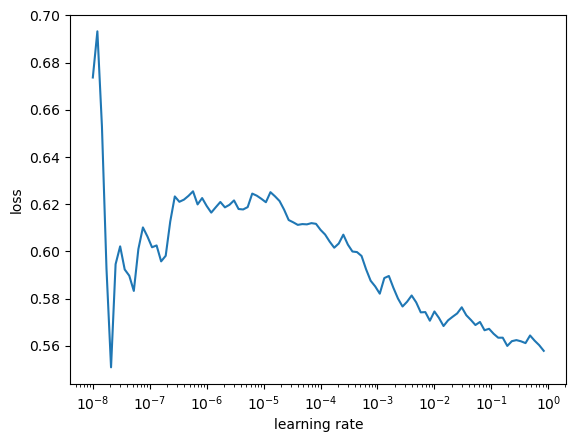

In [33]:
# learning rate 최적화(callback을 이용하는 방법)
# 기존 고양이와 강아지 이진 학습하는 코드를 예를 들어서 알아보아요!

import os # 폴더 경로 생성하기 위해
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator # 입력데이터 처리
from tensorflow.keras.applications import VGG16  
# VGG16은 성능은 좋지 않지만 알기 쉬운 pretrained network. 나중에는 EfficientNet 이거 사용함
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

train_dir = './data/cat_dog_small/train'  # 학습용 이미지가 들어가 있는 폴더(상대경로)
validation_dir = './data/cat_dog_small/validation'

# ImageDataGenerator를 생성. 당연히 2개 생성

# train용 1개 - 증식설정이 들어가야되요
train_datagen = ImageDataGenerator(rescale=1/255.0,
                                  rotation_range=30,
                                  width_shift_range=0.1,
                                  height_shift_range=0.1,
                                  shear_range=0.2,
                                  zoom_range=0.2,
                                  horizontal_flip=True,
                                  vertical_flip=False,
                                  fill_mode='nearest')

# validation용 1개 -평가에는 증식이 들어가면 안되요!
validation_datagen = ImageDataGenerator(rescale=1/255.0)

# ImageDataGenerator 설정
train_generator = train_datagen.flow_from_directory(
    train_dir,
    classes=['cats','dogs'],
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    classes=['cats','dogs'],
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

# model 구현

model_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150,150,3))

model_base.trainable = False  # 있는 것을 그대로 사용할거란 코드, VGG16 안의 convolution Layer를 동결(중요!!)하는 코드

model = Sequential()

model.add(model_base)  # 특징 추출하는 부분(이미지 1장이 3차원)

model.add(Flatten())  # classifier로 넣어야 해요(이미지 1장이 1차원)

# hidden layer
model.add(Dense(units=128))
model.add(BatchNormalization())  # 성능 향상을 위해 BatchNormalization을 사용해요
model.add(Activation('relu'))

model.add(Dropout(rate=0.2))  
# Dropout은 Activation 뒤에 위차하는게 좋아요(Dense뒤에 위치)
# 일반적으로 convolution Layer에서는 Dropout을 사용하지 않아요

# 규제를 너무 많이 넣으면 오히려 성능이 떨어질 수 있다.
# Batch랑 Drop을 둘 다 있으면 규제가 두개니까 드랍아웃을 보통 0.2로 많이 잡음. 드랍만 있으면 일반적으로 0.5 사용

# output layer
model.add(Dense(units=1,
               activation='sigmoid'))

initial_lr = 1e-8

# Learning Rate 알아내는 사용자 정의 Callback
class LRFinderCallback(tf.keras.callbacks.Callback):
    def __init__(self, min_lr=1e-8, max_lr=10, steps=100):
        super(LRFinderCallback, self).__init__()
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.total_steps = steps
        self.history = {'lr': [], 'loss': []}

    def on_batch_end(self, batch, logs=None):
        lr = self.min_lr * (self.max_lr / self.min_lr) ** (batch / self.total_steps)
        tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        self.history['lr'].append(lr)
        self.history['loss'].append(logs['loss'])

# 콜백 인스턴스 생성
lr_finder = LRFinderCallback(min_lr=1e-8, max_lr=1, steps=100)

# model 설정
model.compile(optimizer=Adam(learning_rate=1e-3),
             loss='binary_crossentropy',
             metrics=['accuracy']) 

# 모델 학습
model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=1,
    validation_data=validation_generator,
    validation_steps=50,
    callbacks=[lr_finder],
    verbose=1
)

plt.plot(lr_finder.history['lr'], lr_finder.history['loss'])
plt.xscale('log')
plt.xlabel('learning rate')
plt.ylabel('loss')

plt.show()          
          

In [34]:
# 또 다른 방법은 optuna(라이브러리) 사용해서 알아내는 방법
# conda install -c conda-forge optuna
import optuna

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.applications import VGG16  
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

train_dir = './data/cat_dog_small/train'
validation_dir = './data/cat_dog_small/validation'

# ImageDataGenerator를 생성
train_datagen = ImageDataGenerator(rescale=1/255.0,
                                  rotation_range=30,
                                  width_shift_range=0.1,
                                  height_shift_range=0.1,
                                  shear_range=0.2,
                                  zoom_range=0.2,
                                  horizontal_flip=True,
                                  vertical_flip=False,
                                  fill_mode='nearest')

validation_datagen = ImageDataGenerator(rescale=1/255.0)

# ImageDataGenerator 설정
train_generator = train_datagen.flow_from_directory(
    train_dir,
    classes=['cats','dogs'],
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    classes=['cats','dogs'],
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

# model 구현
model_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150,150,3))

model_base.trainable = False 
model = Sequential()

model.add(model_base)

model.add(Flatten())

# hidden layer
model.add(Dense(units=128))
model.add(BatchNormalization())  
model.add(Activation('relu'))

model.add(Dropout(rate=0.2))  

# output layer
model.add(Dense(units=1,
               activation='sigmoid'))


def objective(trial):
    lr = trial.suggest_loguniform('learning_rate',1e-7,1e-1)
    model.compile(optimizer=Adam(learning_rate=lr),
             loss='binary_crossentropy',
             metrics=['accuracy']) 
    history = model.fit(train_generator,
                   steps_per_epoch=100,
                   epochs=10,
                   validation_data=validation_generator,
                   validation_steps=50,
                   verbose=1)
    return history.history['val_accuracy'][-1]

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print(f'최적의 parameter : study.best_params{learning_rate}')

